In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import scale
from sklearn.cluster import KMeans

In [7]:
np.random.seed(200801)

In [8]:
titanic = pd.read_csv("/Users/gabychuX/Documents/GitHub/portafolio-python/data/titanic.csv")

In [9]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
titanic.rename(columns= {col: col.lower().replace ('/',"_").replace(" ","_")
                         for col in titanic.columns.values}, inplace = True)
titanic.head ()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Transformacion de variables

In [11]:
## modificamos sex
titanic.sex.mask (titanic.sex == 'female', '1', inplace=True)
titanic.sex.mask (titanic.sex == 'male', '0', inplace=True)

titanic ['sex'] = titanic.sex.astype ('int')

titanic.head()

/var/folders/5_/n8vty92j30zb51__zv9xgf3c0000gp/T/ipykernel_7509/1241070802.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.sex.mask (titanic.sex == 'female', '1', inplace=True)
/var/folders/5_/n8vty92j30zb51__zv9xgf3c0000gp/T/ipykernel_7509/1241070802.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [12]:
titanic.describe()

,passengerid,survived,pclass,sex,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
dataset = titanic.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1)
dataset.head()

,passengerid,survived,pclass,sex,age,sibsp,parch,fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833
2,3,1,3,1,26.0,0,0,7.9250
3,4,1,1,1,35.0,1,0,53.1000
4,5,0,3,0,35.0,0,0,8.0500


In [14]:
print(dataset.isnull().sum())

passengerid      0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
dtype: int64


In [15]:
dataset = dataset.fillna(dataset.mean(numeric_only=True))

### Escalando los datos

In [16]:
dataset_scaled = scale (dataset)
dataset_scaled [:4]

array([[-1.73010796, -0.78927234,  0.82737724, -0.73769513, -0.5924806 ,
         0.43279337, -0.47367361, -0.50244517],
       [-1.72622007,  1.2669898 , -1.56610693,  1.35557354,  0.63878901,
         0.43279337, -0.47367361,  0.78684529],
       [-1.72233219,  1.2669898 ,  0.82737724,  1.35557354, -0.2846632 ,
        -0.4745452 , -0.47367361, -0.48885426],
       [-1.71844431,  1.2669898 , -1.56610693,  1.35557354,  0.40792596,
         0.43279337, -0.47367361,  0.42073024]])

### KMEANS

In [17]:
KMeans_4 = KMeans (n_clusters=4)
m_4 = KMeans_4.fit(dataset_scaled)
m_4.labels_[:10]

array([3, 0, 1, 0, 3, 3, 3, 2, 1, 1], dtype=int32)

In [18]:
m_4.cluster_centers_

array([[ 1.20262002e-01,  9.38997068e-01, -1.55142297e+00,
         4.82308081e-01,  4.67462133e-01, -1.39318543e-03,
         1.27939738e-01,  1.37757311e+00],
       [-1.30860454e-01,  8.49050343e-01,  4.04139189e-01,
         8.53529426e-01, -4.21364541e-01, -1.09396751e-01,
         7.12888976e-02, -3.25257190e-01],
       [-2.28065997e-01, -6.05677502e-01,  8.06006849e-01,
         3.08939203e-01, -8.56749681e-01,  2.78215214e+00,
         2.27492697e+00,  8.31836390e-02],
       [ 5.95320684e-02, -7.69964710e-01,  2.54289485e-01,
        -7.18040027e-01,  1.77082938e-01, -3.02023075e-01,
        -3.89171729e-01, -3.50209935e-01]])

In [19]:
m_4.n_iter_

18

In [20]:
sse_4 = m_4.inertia_
sse_4

4229.043667865164

## Métricas de desempeño

#### Tamaño de los clusters

In [21]:
titanic ['labels'] = m_4.labels_
titanic.groupby(['labels'], as_index=False)['survived']\
.count()\
.rename(columns={'survived': 'count'})

,labels,count
0,0,163
1,1,246
2,2,56
3,3,426


## Gráfica del codo
### Probaremos hacer de 2 a 10 grupos para realizar la gráfica del codo

In [22]:
def generate_groups (dataset_scaled):
    clusters_data = []

    for i in range (2,11):
        kmeans = KMeans (n_clusters=i)
        m = kmeans.fit(dataset_scaled)
        clusters_data.append({'n_clusters': i, 'sse': m.inertia_})
    return clusters_data

In [23]:
generate_groups (dataset_scaled)

[{'n_clusters': 2, 'sse': 5727.216308791705},
 {'n_clusters': 3, 'sse': 4904.271021968632},
 {'n_clusters': 4, 'sse': 4468.186382182341},
 {'n_clusters': 5, 'sse': 3876.8464244601555},
 {'n_clusters': 6, 'sse': 3504.0405890966767},
 {'n_clusters': 7, 'sse': 3247.3437288656532},
 {'n_clusters': 8, 'sse': 3243.061788360687},
 {'n_clusters': 9, 'sse': 2902.834436974448},
 {'n_clusters': 10, 'sse': 2827.515700345482}]

In [24]:
clusters_data = generate_groups (dataset_scaled)

In [25]:
elbow_df = pd.DataFrame(clusters_data, columns= ['n_clusters', 'sse'])
elbow_df

,n_clusters,sse
0,2,5842.016253
1,3,4852.985989
2,4,4229.043668
3,5,3863.546619
4,6,3491.706131
5,7,3318.868196
6,8,3194.667237
7,9,3100.560036
8,10,2727.121277


<Axes: xlabel='n_clusters', ylabel='sse'>

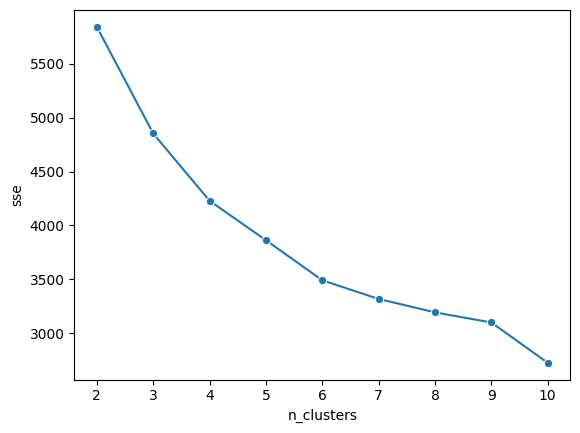

In [26]:
sns.lineplot (x='n_clusters', y='sse', data=elbow_df, marker = "o")

###  ¿Qué pasa ssi solo ocupamos el precio del boleto y la edad?

In [27]:
dataset_2 = dataset [['fare','age']]

In [28]:
dataset_scaled = scale(dataset_2)
dataset_scaled[:4]

array([[-0.50244517, -0.5924806 ],
       [ 0.78684529,  0.63878901],
       [-0.48885426, -0.2846632 ],
       [ 0.42073024,  0.40792596]])

In [29]:
results = generate_groups (dataset_scaled)

In [30]:
elbow_df = pd.DataFrame(results, columns=['n_clusters', 'sse'])
elbow_df

,n_clusters,sse
0,2,1189.889955
1,3,810.062279
2,4,543.354610
3,5,407.058093
4,6,350.466953
5,7,273.415709
6,8,215.912997
7,9,181.627619
8,10,172.045120


<Axes: xlabel='n_clusters', ylabel='sse'>

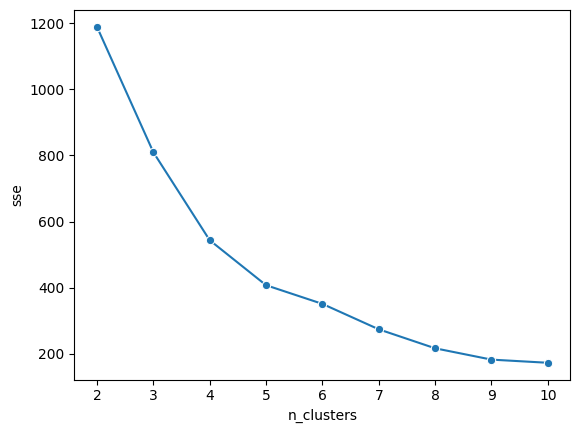

In [31]:
sns.lineplot (x='n_clusters', y= 'sse', data=elbow_df, marker ="o")

## Visualizar centroides

In [32]:
kmeans = KMeans (n_clusters= 3)
m_3 = kmeans.fit (dataset_scaled)

In [33]:
results = pd.DataFrame ({'fare': dataset_scaled [:,0], 'age': dataset_scaled [:,1]})
results ['group'] = m_3.labels_
results ['group'] = results.group.astype(str)

In [34]:
centroids = pd.DataFrame ({'fare': m_3.cluster_centers_[:,0], 'age': m_3.cluster_centers_[:,1]})
centroids['group'] = "C"

In [35]:
df = pd.concat ([results, centroids])

<Axes: xlabel='fare', ylabel='age'>

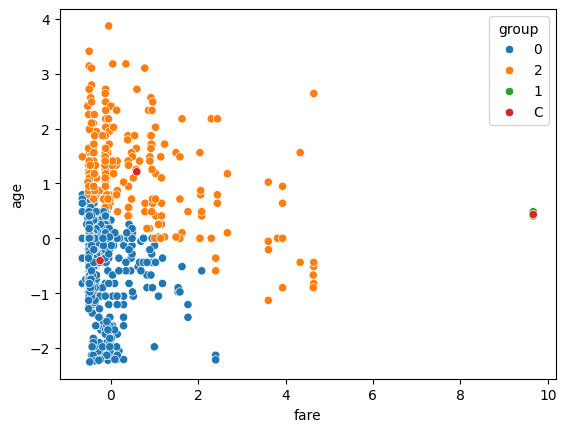

In [36]:
sns.scatterplot(x='fare', y='age', data=df, hue="group")